<a href="https://colab.research.google.com/github/arthyaroul/pilotage-risques-chantier/blob/main/pilotage-risques-chantier/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 · Exploration des données (EDA)

**Projet :** Pilotage des risques de chantier · Arthy Aroul & Aurélie Mahé · Bootcamp Data Essentials, Jedha (2026)

**Question du projet :** peut-on prédire le niveau de risque d'un chantier à partir de ses indicateurs opérationnels et environnementaux ?

**Objectif de ce notebook :** comprendre le dataset avant toute modélisation (qualité, cohérence, distribution de la cible, liens entre variables et risque) et repérer les pièges, notamment les fuites de données.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Chargement des données

In [8]:
# Chemin du fichier (voir data/README.md pour télécharger le dataset)
# Sur Google Colab : téléverser le CSV puis utiliser "/content/bim_ai_civil_engineering_dataset.csv"
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/bim_ai_civil_engineering_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"{df.shape[0]} projets, {df.shape[1]} variables")

df["Start_Date"] = pd.to_datetime(df["Start_Date"])
df["End_Date"] = pd.to_datetime(df["End_Date"])
df.head()

1000 projets, 28 variables


,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,...,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,1.505450e+07,2.793720e+06,699,813.914852,...,25202.994687,244.843310,6602,76.300184,8,6.192198,52.988330,0,95.006343,High
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3.507054e+06,1.137777e+06,269,384.118221,...,49066.172542,263.123025,7121,63.527671,5,2.134473,50.885745,0,25.294824,Low
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,...,48192.547163,608.985023,9956,47.099444,2,3.113728,93.905836,0,97.478830,Medium
3,PJT_4,Dam,Houston,2020-01-04,2022-04-12,24499306,2.946966e+07,4.970354e+06,809,974.565655,...,19811.151750,673.574344,3725,86.846394,5,4.070101,90.454316,1,95.098131,High
4,PJT_5,Dam,Seattle,2020-01-05,2022-02-12,1749971,2.329338e+06,5.793670e+05,354,347.990127,...,44866.565169,765.476122,4368,61.827163,6,2.759351,78.391069,0,43.624985,Low


## 2. Qualité des données

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Project_ID             1000 non-null   object        
 1   Project_Type           1000 non-null   object        
 2   Location               1000 non-null   object        
 3   Start_Date             1000 non-null   datetime64[ns]
 4   End_Date               1000 non-null   datetime64[ns]
 5   Planned_Cost           1000 non-null   int64         
 6   Actual_Cost            1000 non-null   float64       
 7   Cost_Overrun           1000 non-null   float64       
 8   Planned_Duration       1000 non-null   int64         
 9   Actual_Duration        1000 non-null   float64       
 10  Schedule_Deviation     1000 non-null   float64       
 11  Vibration_Level        1000 non-null   float64       
 12  Crack_Width            1000 non-null   float64       
 13  Load

In [10]:
print("Valeurs manquantes :", df.isnull().sum().sum())
print("Lignes dupliquées  :", df.duplicated().sum())
print("Projets uniques    :", df["Project_ID"].nunique(), "/", len(df))

Valeurs manquantes : 0
Lignes dupliquées  : 0
Projets uniques    : 1000 / 1000


Le dataset est complet : aucune valeur manquante, aucun doublon, un identifiant unique par projet. Il ne demande pas de nettoyage, ce qui est déjà inhabituel pour des données réelles.

### Cohérence des variables calculées

On vérifie que les dépassements correspondent bien à la différence entre réel et prévu.

In [11]:
ecart_cout = (df["Cost_Overrun"] - (df["Actual_Cost"] - df["Planned_Cost"])).abs().max()
ecart_delai = (df["Schedule_Deviation"] - (df["Actual_Duration"] - df["Planned_Duration"])).abs().max()

print(f"Écart maximal Cost_Overrun vs (réel - prévu)      : {ecart_cout:.1e}")
print(f"Écart maximal Schedule_Deviation vs (réel - prévu) : {ecart_delai:.1e}")

Écart maximal Cost_Overrun vs (réel - prévu)      : 9.3e-09
Écart maximal Schedule_Deviation vs (réel - prévu) : 2.6e-13


Les écarts sont de l'ordre de l'arrondi informatique : `Cost_Overrun` et `Schedule_Deviation` sont exactement « réel − prévu ». Ce sont des **informations redondantes**, à garder en tête pour la modélisation.

## 3. Statistiques descriptives par famille de variables

In [12]:
familles = {
    "Budget": ["Planned_Cost", "Actual_Cost", "Cost_Overrun"],
    "Délais": ["Planned_Duration", "Actual_Duration", "Schedule_Deviation"],
    "Sécurité": ["Accident_Count", "Safety_Risk_Score"],
    "Ressources": ["Energy_Consumption", "Material_Usage", "Labor_Hours", "Equipment_Utilization"],
    "Conditions": ["Temperature", "Humidity", "Air_Quality_Index", "Vibration_Level"],
}

for nom, colonnes in familles.items():
    print(f"\n--- {nom} ---")
    display(df[colonnes].describe().round(2))


--- Budget ---


,Planned_Cost,Actual_Cost,Cost_Overrun
count,1000.00,1000.00,1000.00
mean,26415087.63,31541079.26,5125991.63
std,14485761.88,18095958.81,5931350.17
min,1045475.00,1180251.53,-4648578.92
25%,14310133.00,16096546.66,581066.14
50%,26908602.00,31339224.46,3326817.48
75%,39570293.25,45327468.95,8665132.39
max,49968538.00,72519386.55,24012292.06



--- Délais ---


,Planned_Duration,Actual_Duration,Schedule_Deviation
count,1000.00,1000.00,1000.00
mean,538.62,645.56,106.94
std,204.53,269.38,110.39
min,180.00,165.28,-79.14
25%,361.00,424.25,22.40
50%,535.50,635.47,84.06
75%,713.00,831.64,173.95
max,899.00,1340.35,446.35



--- Sécurité ---


,Accident_Count,Safety_Risk_Score
count,1000.00,1000.00
mean,4.57,5.33
std,2.88,2.56
min,0.00,1.00
25%,2.00,3.06
50%,5.00,5.34
75%,7.00,7.49
max,9.00,9.97



--- Ressources ---


,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization
count,1000.00,1000.00,1000.00,1000.00
mean,27403.79,543.40,5395.22,69.45
std,13009.21,263.35,2617.17,17.36
min,5054.16,101.20,1001.00,40.02
25%,16153.65,311.35,3154.75,54.15
50%,27042.80,534.19,5371.00,69.53
75%,38909.34,773.81,7616.50,84.78
max,49941.43,998.96,9997.00,100.00



--- Conditions ---


,Temperature,Humidity,Air_Quality_Index,Vibration_Level
count,1000.00,1000.00,1000.00,1000.00
mean,17.11,55.48,174.77,1.04
std,15.31,20.24,72.25,0.55
min,-10.00,20.02,50.00,0.11
25%,4.58,37.63,112.75,0.57
50%,17.19,55.74,177.00,1.04
75%,29.87,73.19,236.00,1.54
max,44.92,89.97,299.00,2.00


In [13]:
for column in ["Project_Type", "Location", "Weather_Condition", "Risk_Level", "Anomaly_Detected"]:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Project_Type ---
Project_Type
Bridge      210
Tunnel      206
Dam         204
Building    190
Road        190
Name: count, dtype: int64

--- Location ---
Location
Los Angeles    211
New York       205
Seattle        205
Houston        190
Chicago        189
Name: count, dtype: int64

--- Weather_Condition ---
Weather_Condition
Rainy     216
Snowy     206
Cloudy    201
Stormy    194
Sunny     183
Name: count, dtype: int64

--- Risk_Level ---
Risk_Level
High      502
Medium    342
Low       156
Name: count, dtype: int64

--- Anomaly_Detected ---
Anomaly_Detected
0    803
1    197
Name: count, dtype: int64


Les modalités de chaque variable catégorielle sont presque parfaitement équilibrées (environ 200 projets par type d'ouvrage, par ville et par météo). Dans la réalité, on n'aurait pas autant de barrages que de routes : c'est un premier indice que les données sont **synthétiques**.

## 4. La variable cible : `Risk_Level`

Risk_Level
Low       0.156
Medium    0.342
High      0.502
Name: proportion, dtype: float64


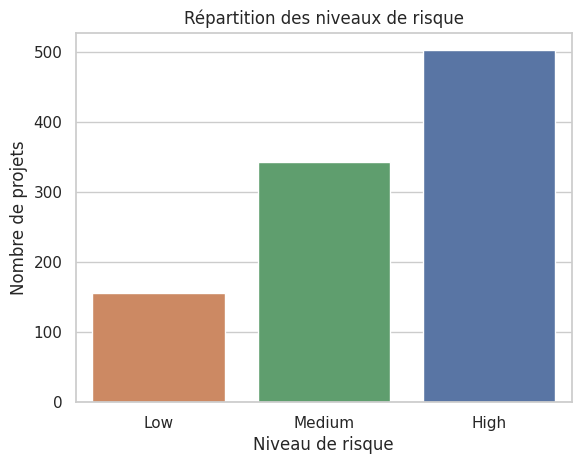

In [14]:
ordre_risque = ["Low", "Medium", "High"]

print(df["Risk_Level"].value_counts(normalize=True).reindex(ordre_risque).round(3))

sns.countplot(data=df, x="Risk_Level", order=ordre_risque, hue="Risk_Level", legend=False)
plt.title("Répartition des niveaux de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre de projets")
plt.show()

Les classes sont **déséquilibrées** : environ 50 % High, 34 % Medium et 16 % Low. Il faudra en tenir compte dans le choix des métriques.

,count,mean,std,min,25%,50%,75%,max
Risk_Level,,,,,,,,
Low,156.0,1.85,0.49,1.00,1.44,1.82,2.25,2.87
Medium,342.0,3.80,1.16,1.04,2.96,3.79,4.69,5.97
High,502.0,7.46,1.48,3.51,6.36,7.48,8.68,9.97


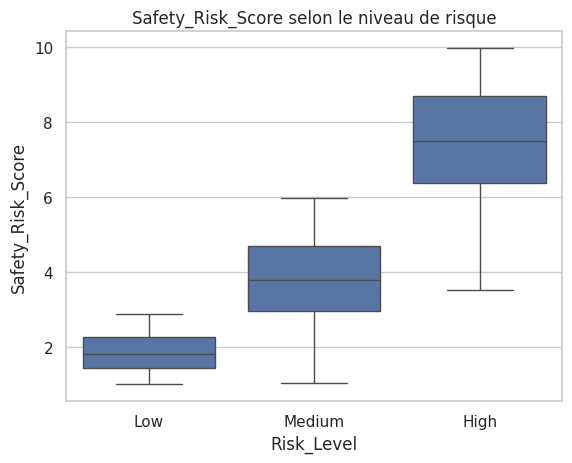

In [15]:
display(df.groupby("Risk_Level")["Safety_Risk_Score"].describe().reindex(ordre_risque).round(2))

sns.boxplot(data=df, x="Risk_Level", y="Safety_Risk_Score", order=ordre_risque)
plt.title("Safety_Risk_Score selon le niveau de risque")
plt.show()

`Risk_Level` est très fortement déterminé par `Safety_Risk_Score` : les projets Low ont un score toujours inférieur à 3, les High sont concentrés en haut de l'échelle. Garder ce score comme variable explicative reviendrait à **donner la réponse au modèle** (fuite de données). Il sera donc retiré de la modélisation.

In [16]:
pd.crosstab(df["Risk_Level"], df["Anomaly_Detected"], normalize="index").reindex(ordre_risque).round(3)

Anomaly_Detected,0,1
Risk_Level,,
Low,1.000,0.000
Medium,0.816,0.184
High,0.733,0.267


Aucun projet Low n'a d'anomalie détectée. `Anomaly_Detected` pourrait donc être liée à la façon dont le risque est calculé : c'est une variable à surveiller.

## 5. Distribution des variables numériques

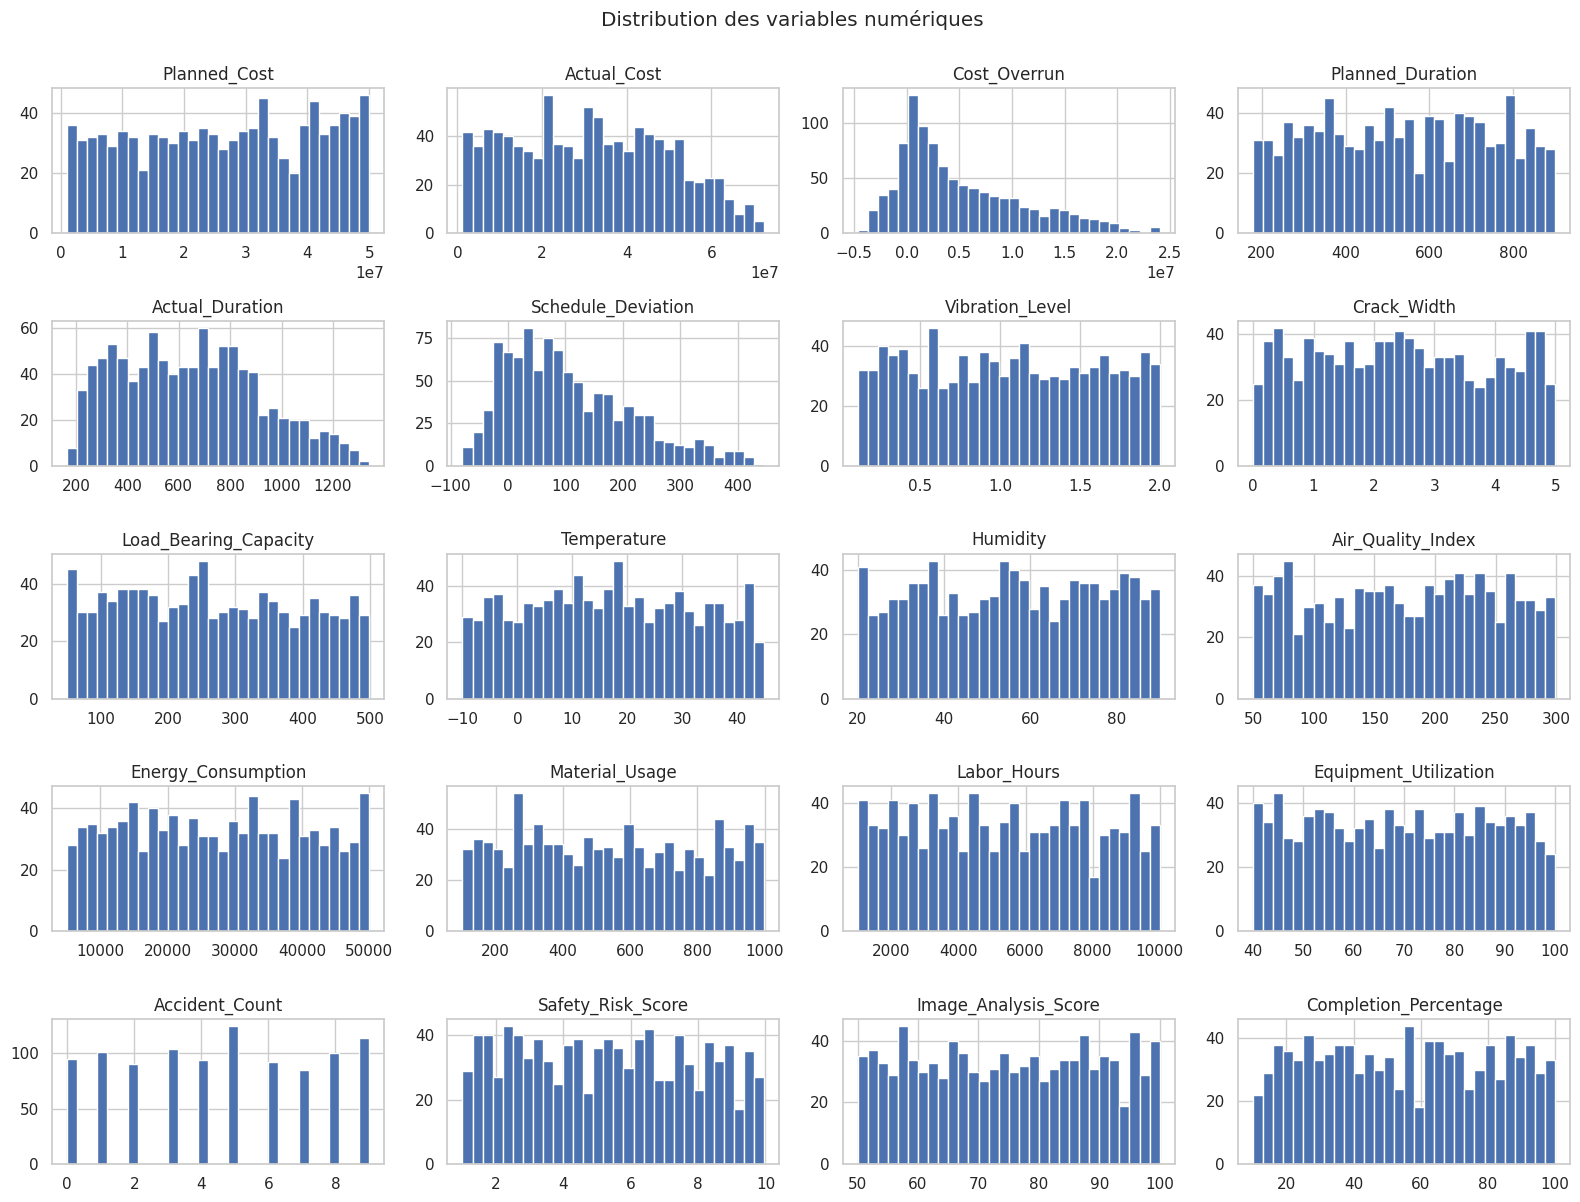

In [17]:
colonnes_num = df.select_dtypes(include="number").columns.drop("Anomaly_Detected")

df[colonnes_num].hist(bins=30, figsize=(16, 12))
plt.suptitle("Distribution des variables numériques", y=1.0)
plt.tight_layout()
plt.show()

La plupart des histogrammes sont **plats** : les valeurs sont réparties uniformément entre un minimum et un maximum. Des données réelles montreraient plutôt des distributions asymétriques (beaucoup de petits chantiers, quelques très gros).

On peut le vérifier : pour une loi uniforme, l'écart-type vaut (max − min) / √12. Un ratio proche de 1 indique une distribution compatible avec une loi uniforme.

In [18]:
ratio_uniforme = (
    df[colonnes_num].std() / ((df[colonnes_num].max() - df[colonnes_num].min()) / np.sqrt(12))
).sort_values()

ratio_uniforme.round(2).to_frame("écart-type / écart-type uniforme")

,écart-type / écart-type uniforme
Cost_Overrun,0.72
Schedule_Deviation,0.73
Actual_Duration,0.79
Actual_Cost,0.88
Temperature,0.97
Planned_Duration,0.99
Crack_Width,0.99
Safety_Risk_Score,0.99
Completion_Percentage,1.00
Load_Bearing_Capacity,1.00


Pour la grande majorité des variables, le ratio est proche de 1 : les données ont très probablement été **générées aléatoirement**, variable par variable. C'est la limite principale du dataset.

## 6. Prévu vs réel

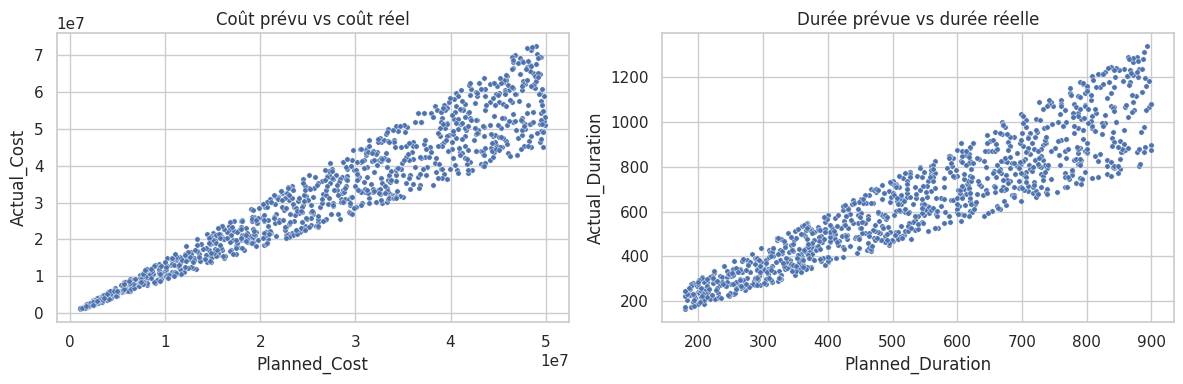

Corrélation coût prévu / réel   : 0.958
Corrélation durée prévue / réelle : 0.928


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x="Planned_Cost", y="Actual_Cost", ax=axes[0], s=15)
axes[0].set_title("Coût prévu vs coût réel")
sns.scatterplot(data=df, x="Planned_Duration", y="Actual_Duration", ax=axes[1], s=15)
axes[1].set_title("Durée prévue vs durée réelle")
plt.tight_layout()
plt.show()

print("Corrélation coût prévu / réel   :", round(df["Planned_Cost"].corr(df["Actual_Cost"]), 3))
print("Corrélation durée prévue / réelle :", round(df["Planned_Duration"].corr(df["Actual_Duration"]), 3))

Le réel suit de près le prévu (corrélations supérieures à 0,9), avec un dépassement moyen d'environ 5 M et de 107 jours. Les projets dépassent plus souvent qu'ils ne restent sous le budget.

## 7. Liens entre les variables et le risque

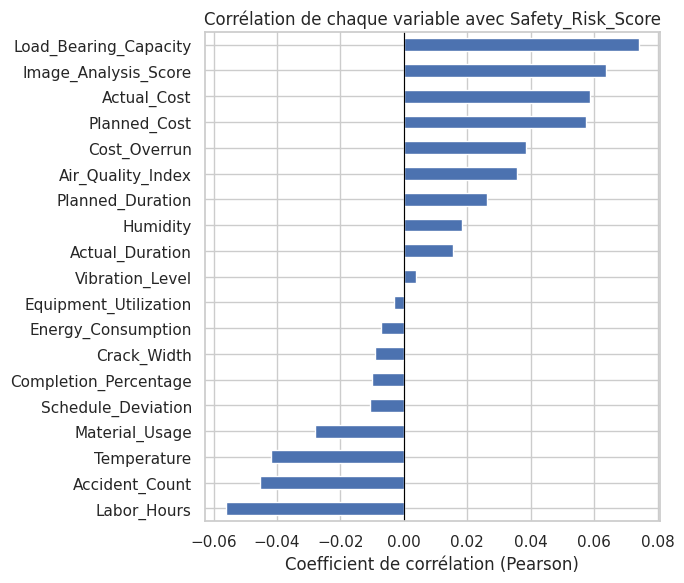

Corrélation maximale en valeur absolue : 0.074


In [20]:
variables_explicatives = colonnes_num.drop(["Safety_Risk_Score"])
correlations = df[variables_explicatives].corrwith(df["Safety_Risk_Score"]).sort_values()

correlations.plot(kind="barh", figsize=(7, 6))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Corrélation de chaque variable avec Safety_Risk_Score")
plt.xlabel("Coefficient de corrélation (Pearson)")
plt.tight_layout()
plt.show()

print("Corrélation maximale en valeur absolue :", round(correlations.abs().max(), 3))

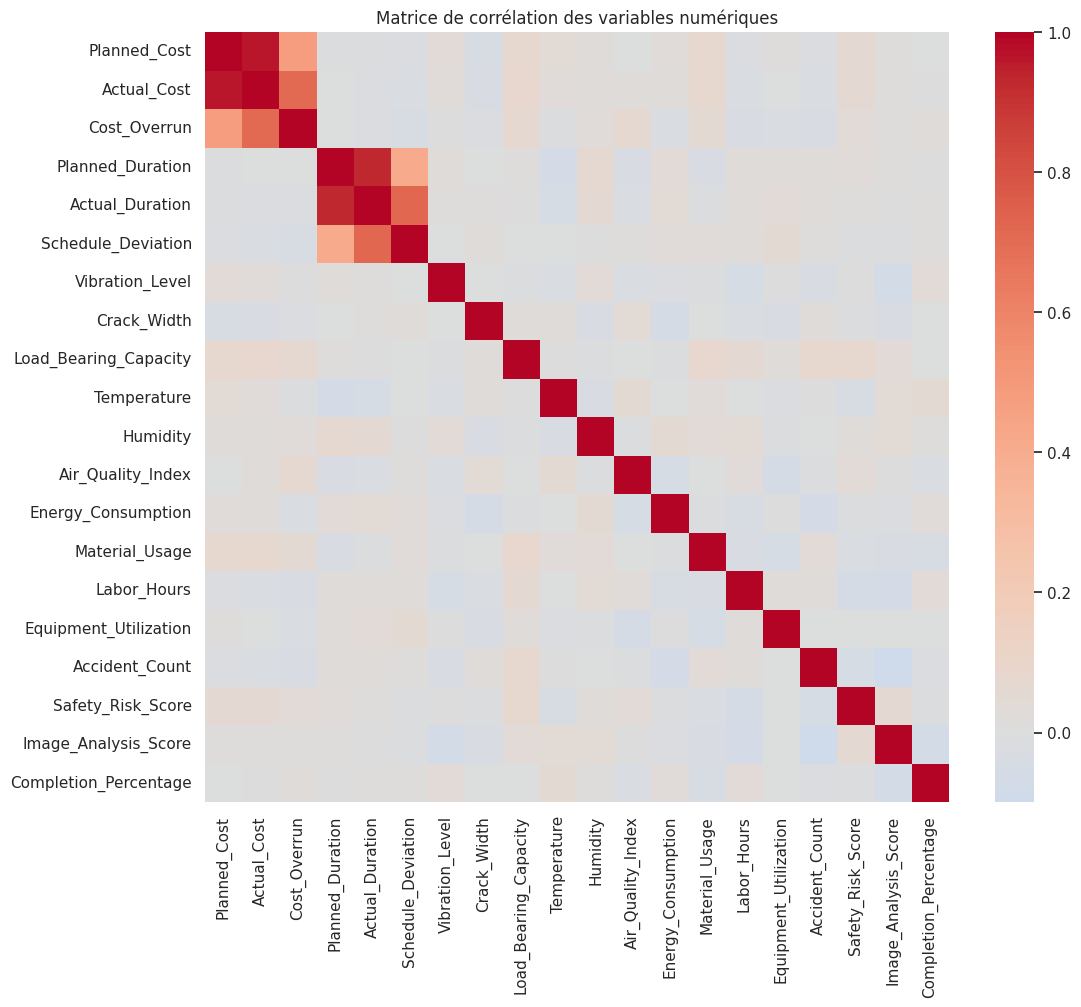

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[colonnes_num].corr(), cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

En dehors des paires évidentes (prévu / réel / dépassement), la matrice est quasiment vide : **aucune variable n'est corrélée au score de risque** (corrélation maximale de l'ordre de 0,07).

### Axe 1 · Planning et pression temporelle

*Les chantiers en avance sont-ils aussi ceux qui ont le moins d'accidents ?*

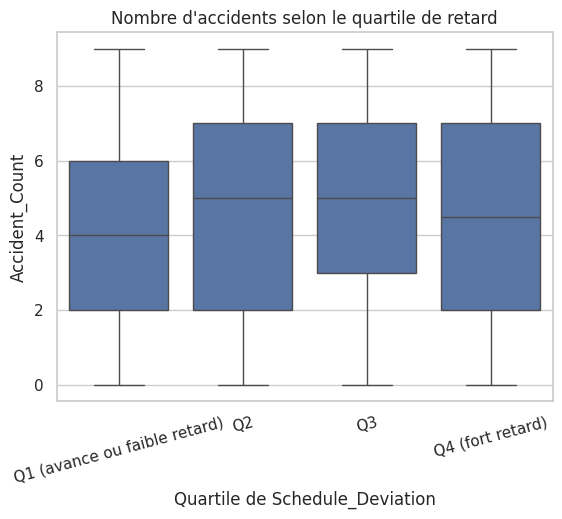

,Accident_Count
Quartile_retard,
Q1 (avance ou faible retard),4.24
Q2,4.81
Q3,4.70
Q4 (fort retard),4.52


In [22]:
df["Quartile_retard"] = pd.qcut(
    df["Schedule_Deviation"], 4,
    labels=["Q1 (avance ou faible retard)", "Q2", "Q3", "Q4 (fort retard)"],
)

sns.boxplot(data=df, x="Quartile_retard", y="Accident_Count")
plt.title("Nombre d'accidents selon le quartile de retard")
plt.xlabel("Quartile de Schedule_Deviation")
plt.xticks(rotation=15)
plt.show()

df.groupby("Quartile_retard", observed=True)["Accident_Count"].mean().round(2)

### Axe 2 · Effectifs

*Existe-t-il un seuil de main-d'œuvre au-delà duquel le risque n'augmente plus ?*

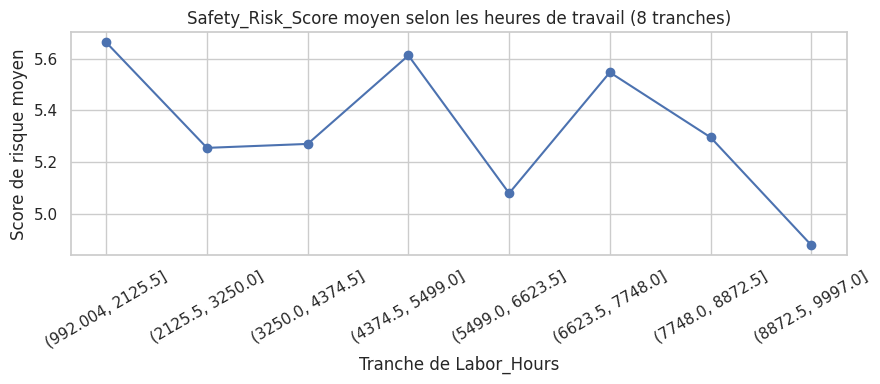

In [23]:
df["Tranche_heures"] = pd.cut(df["Labor_Hours"], bins=8)
moyenne_par_tranche = df.groupby("Tranche_heures", observed=True)["Safety_Risk_Score"].mean()

moyenne_par_tranche.plot(marker="o", figsize=(9, 4))
plt.title("Safety_Risk_Score moyen selon les heures de travail (8 tranches)")
plt.xlabel("Tranche de Labor_Hours")
plt.ylabel("Score de risque moyen")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Axe 3 · Dérives budgétaires et climat

*Le dépassement budgétaire est-il plus lié au planning qu'au climat ?*

In [24]:
variables_axe3 = ["Schedule_Deviation", "Actual_Duration", "Temperature", "Humidity", "Air_Quality_Index"]
df[variables_axe3].corrwith(df["Cost_Overrun"]).round(3).to_frame("Corrélation avec Cost_Overrun")

,Corrélation avec Cost_Overrun
Schedule_Deviation,-0.040
Actual_Duration,-0.015
Temperature,-0.011
Humidity,0.028
Air_Quality_Index,0.067


Sur ces trois axes, les écarts observés restent faibles et sans tendance claire, ce qui est cohérent avec l'absence de corrélation vue plus haut.

### Focus · Consommation énergétique

Dans la réalité, un barrage ou un tunnel consomme beaucoup plus d'énergie qu'une route. Voyons si le dataset reflète ces différences.

,mean,median
Project_Type,,
Bridge,27806.0,29053.0
Building,26852.0,26748.0
Dam,27482.0,25919.0
Road,27230.0,26652.0
Tunnel,27585.0,27020.0


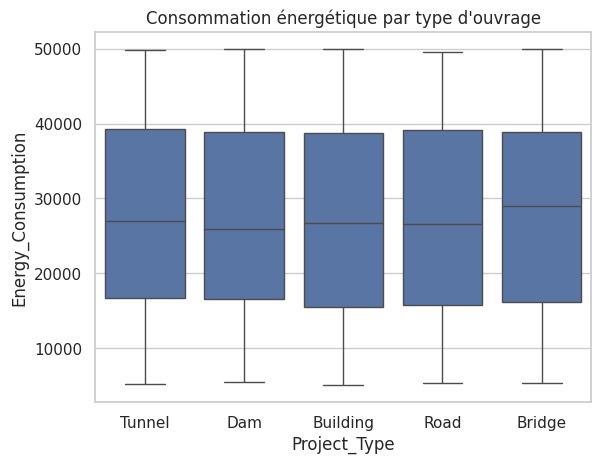

,Corrélation avec Energy_Consumption
Material_Usage,-0.012
Labor_Hours,-0.042
Equipment_Utilization,0.008
Planned_Cost,0.032


In [25]:
display(df.groupby("Project_Type")["Energy_Consumption"].agg(["mean", "median"]).round(0))

sns.boxplot(data=df, x="Project_Type", y="Energy_Consumption")
plt.title("Consommation énergétique par type d'ouvrage")
plt.show()

df[["Material_Usage", "Labor_Hours", "Equipment_Utilization", "Planned_Cost"]].corrwith(
    df["Energy_Consumption"]
).round(3).to_frame("Corrélation avec Energy_Consumption")

La consommation d'énergie ne dépend ni du type d'ouvrage, ni des heures de travail, ni des matériaux, ni du budget. Sur des données réelles, ces liens seraient forts : c'est une confirmation supplémentaire du caractère synthétique du dataset.

## 8. Conclusions de l'EDA

1. **Données propres mais synthétiques** : aucune valeur manquante, catégories quasi équilibrées et distributions uniformes. Les liens attendus dans la réalité (type d'ouvrage et énergie, par exemple) sont absents.
2. **Variables redondantes** : `Cost_Overrun` et `Schedule_Deviation` sont exactement « réel − prévu ».
3. **Fuite de données** : `Risk_Level` est dérivé de `Safety_Risk_Score`, qui doit être exclu des variables explicatives. `Anomaly_Detected` est à surveiller.
4. **Signal très faible** : aucune variable n'est corrélée au risque (maximum de l'ordre de 0,07). Il faut s'attendre à des modèles peu performants, et donc les comparer à une baseline naïve.
5. **Cible déséquilibrée** : les métriques devront en tenir compte (F1 macro et surtout MCC plutôt que l'accuracy).